/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.777e-04  1.594e+01  y = 0.049034
3           2.479e-04  5.716e-01  y = x₀ * 0.074044
5           2.441e-04  7.827e-03  y = (x₀ * 0.080317) - 0.0049908
7           2.429e-04  2.425e-03  y = x₀ * ((x₀ * 0.018811) + 0.057946)
9           2.429e-04  2.980e-07  y = ((0.057943 - (x₀ * 0.98119)) + x₀) * x₀
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic expression:
complexity                                    3
loss                                   0.000248
equation                        x0 * 0.07404412
score                                  0.571632
sympy_format                      x0*0.07404412
lambda_format    PySRFunction(X=>x0*0.07404412)
Name: 1, dtype: object

Sympy expression:
x0*0.07404412

LaTeX expression:
x_{0} \cdot 0.0741


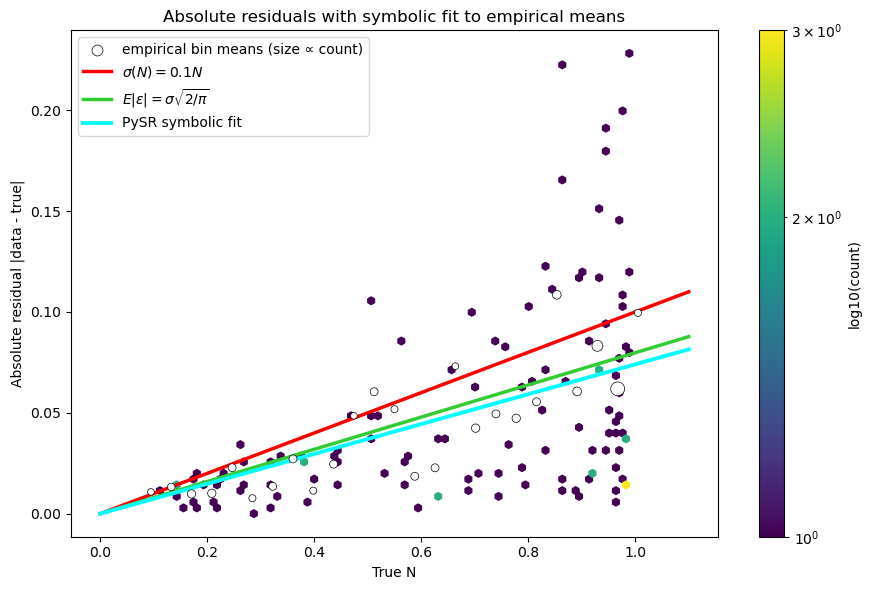

  - /var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/tmpkwx9wmgh/20260308_211526_yvLLO5/hall_of_fame.csv


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pysr import PySRRegressor

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
n_ics = 5
N0_list = np.random.uniform(0.01, 0.25, size=n_ics).tolist()

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


def sigma_true(N):
    return 0.1 * N


# ============================================================
# 2. RK4 integrator
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


# ============================================================
# 3. Generate synthetic observed data
# ============================================================
y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        noise = sigma_true(y_true) * torch.randn_like(y_true)
        y_data = y_true + noise

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)
y_data_all = torch.stack(y_data_list, dim=0)
residuals_all = y_data_all - y_true_all
abs_residuals = torch.abs(residuals_all)

N_true_flat = y_true_all.squeeze(-1).reshape(-1).cpu().numpy()
abs_res_flat = abs_residuals.squeeze(-1).reshape(-1).cpu().numpy()

N_grid_np = N_grid.squeeze(-1).cpu().numpy()
sigma_grid_np = sigma_true(N_grid).squeeze(-1).cpu().numpy()
expected_abs = sigma_grid_np * np.sqrt(2 / np.pi)


# ============================================================
# 4. Build empirical means from bins
# ============================================================
bins = np.linspace(0.0, 1.1, 30)
centers = 0.5 * (bins[:-1] + bins[1:])
means = []
counts = []

for i in range(len(bins) - 1):
    mask = (N_true_flat >= bins[i]) & (N_true_flat < bins[i + 1])
    if np.any(mask):
        means.append(abs_res_flat[mask].mean())
        counts.append(mask.sum())
    else:
        means.append(np.nan)
        counts.append(0)

means = np.array(means, dtype=np.float64)
counts = np.array(counts, dtype=np.float64)

valid = ~np.isnan(means)
X_emp = centers[valid][:, None]          # shape [n_bins, 1]
Y_emp = means[valid]                     # shape [n_bins]
W_emp = counts[valid]                    # weights by number of points in bin


# ============================================================
# 5. Fit symbolic expression with PySR
# ============================================================
# We use count weights so bins with more residual points have
# more influence on the symbolic fit.
#
# Because the target should be nonnegative and increasing-ish,
# we keep the operator set simple. You can widen this later.
model = PySRRegressor(
    niterations=10,
    populations=8,
    population_size=10,
    maxsize=10,
    maxdepth=8,
    binary_operators=["+", "*", "-", "/"],
    unary_operators=[],
    model_selection="best",
    loss="loss(prediction, target, weight) = weight * (prediction - target)^2",
    verbosity=1,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
)

model.fit(X_emp, Y_emp, weights=W_emp)

# Best symbolic expression
print("\nBest symbolic expression:")
print(model.get_best())

# Evaluate best symbolic model on grid
symbolic_pred = model.predict(N_grid_np.reshape(-1, 1))

# Optional: pretty export forms
try:
    print("\nSympy expression:")
    print(model.sympy())
except Exception:
    pass

try:
    print("\nLaTeX expression:")
    print(model.latex())
except Exception:
    pass


# ============================================================
# 6. Plot
# ============================================================
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    N_true_flat,
    abs_res_flat,
    gridsize=70,
    mincnt=1,
    bins="log"
)
plt.colorbar(hb, label="log10(count)")

marker_sizes = 20 + 80 * (W_emp / W_emp.max())
plt.scatter(
    X_emp[:, 0],
    Y_emp,
    s=marker_sizes,
    color="white",
    edgecolor="black",
    linewidth=0.5,
    label="empirical bin means (size ∝ count)",
    zorder=3
)

plt.plot(N_grid_np, sigma_grid_np, color="red", lw=2.5, label=r"$\sigma(N)=0.1N$")
plt.plot(N_grid_np, expected_abs, color="limegreen", lw=2.5, label=r"$E|\epsilon|=\sigma\sqrt{2/\pi}$")
plt.plot(N_grid_np, symbolic_pred, color="cyan", lw=2.8, label="PySR symbolic fit")

plt.xlabel("True N")
plt.ylabel("Absolute residual |data - true|")
plt.title("Absolute residuals with symbolic fit to empirical means")
plt.legend()
plt.tight_layout()
plt.show()

Number of non-empty PINN bins: 26
Bin counts: [ 5  7  7  5  5  5  6  2  5  5  2  5  3  3  5  3  4  5  3  6  5  6  8  9
 13 12]


/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:1017: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!
[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.556e-04  1.594e+01  y = 0.040193
3           1.270e-04  8.208e-01  y = x₀ * 0.07266
5           1.268e-04  4.781e-04  y = (x₀ * 0.071721) - -0.00069246
7           1.206e-04  2.521e-02  y = (x₀ * 0.072096) + (0.000229 / x₀)
───────────────────────────────────────────────────────────────────────────────────────────────────

Best symbolic expression for PINN empirical mean residual:
complexity                                    3
loss                                   0.000127
equation                        x0 * 0.07266012
score                                  0.820835
sympy_format                      x0*0.07266012
lambda_format    PySRFunction(X=>x0*0.07266012)
Name: 1, dtype: object
ideal value 0.7978845608028654

Sympy form:
x0*0.07266012

LaTeX form:
x_{0} \cdot 0.0727


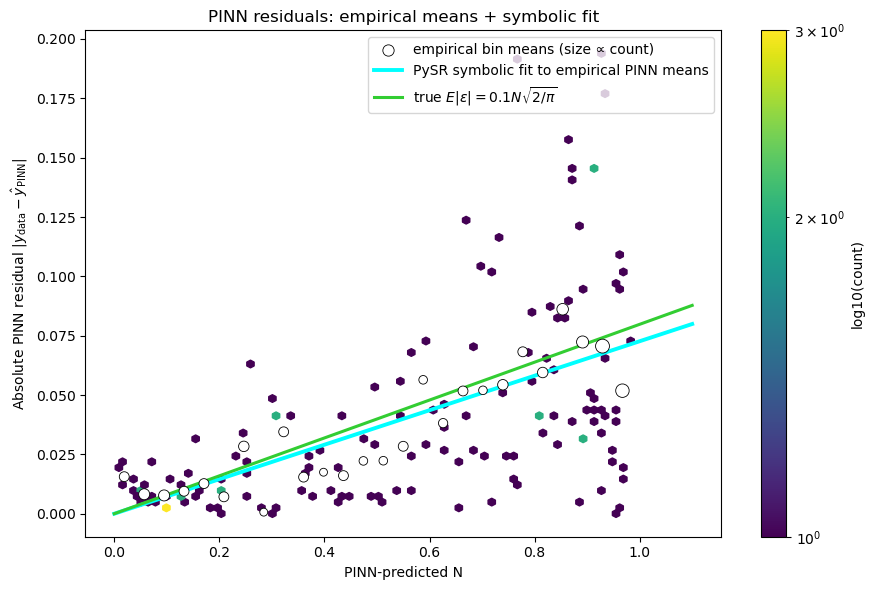

  - /var/folders/dn/jj6zl9nx6s541bq88x9x4zvm0000gn/T/tmpfxoiqbx0/20260308_214605_noj6Qg/hall_of_fame.csv


In [11]:
from pysr import PySRRegressor

# ============================================================
# A. Build empirical means from PINN residuals
#    using the already-computed quantities:
#      N_pinn_sigma_all, resid_pinn_sigma_all, N_grid
# ============================================================
N_pinn_np = N_pinn_sigma_all.detach().cpu().numpy().reshape(-1)
abs_resid_pinn_np = np.abs(resid_pinn_sigma_all.detach().cpu().numpy().reshape(-1))

# choose bins over the support of the PINN-predicted states
N_max_fit = max(float(N_pinn_np.max()), float(N_grid.max().item()))
bins = np.linspace(0.0, N_max_fit, 30)
centers = 0.5 * (bins[:-1] + bins[1:])

means = []
counts = []

for i in range(len(bins) - 1):
    mask = (N_pinn_np >= bins[i]) & (N_pinn_np < bins[i + 1])
    if np.any(mask):
        means.append(abs_resid_pinn_np[mask].mean())
        counts.append(mask.sum())
    else:
        means.append(np.nan)
        counts.append(0)

means = np.array(means, dtype=np.float64)
counts = np.array(counts, dtype=np.float64)

valid = ~np.isnan(means)

X_emp_pinn = centers[valid][:, None]   # shape [n_bins_nonempty, 1]
Y_emp_pinn = means[valid]              # shape [n_bins_nonempty]
W_emp_pinn = counts[valid]             # weight by number of points in bin

print("Number of non-empty PINN bins:", len(X_emp_pinn))
print("Bin counts:", W_emp_pinn.astype(int))


# ============================================================
# B. Fit symbolic expression to empirical PINN mean residuals
#    weighted by bin counts
# ============================================================
pysr_model_pinn = PySRRegressor(
    niterations=10,
    populations=10,
    population_size=40,
    maxsize=10,
    maxdepth=8,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=[],
    model_selection="best",
    loss="loss(prediction, target, weight) = weight * (prediction - target)^2",
    verbosity=1,
    progress=True,
    temp_equation_file=True,
    delete_tempfiles=True,
)

pysr_model_pinn.fit(X_emp_pinn, Y_emp_pinn, weights=W_emp_pinn)

print("\nBest symbolic expression for PINN empirical mean residual:")
print(pysr_model_pinn.get_best())

print("ideal value", np.sqrt(2 / np.pi))
try:
    print("\nSympy form:")
    print(pysr_model_pinn.sympy())
except Exception:
    pass

try:
    print("\nLaTeX form:")
    print(pysr_model_pinn.latex())
except Exception:
    pass



sigma_grid_np = sigma_true(N_grid).squeeze(-1).cpu().numpy()
expected_abs = sigma_grid_np * np.sqrt(2 / np.pi)

# ============================================================
# C. Evaluate symbolic fit on the same N_grid used elsewhere
# ============================================================
N_grid_np = N_grid.detach().cpu().numpy().reshape(-1, 1)
symbolic_pinn_mean = pysr_model_pinn.predict(N_grid_np)


# ============================================================
# D. Optional reference curve from the known true noise law
#    Since data were generated with sigma(N)=0.1N and
#    E|epsilon| = sigma*sqrt(2/pi)
# ============================================================
expected_abs_true = 0.1 * N_grid_np.squeeze() * np.sqrt(2 / np.pi)


# ============================================================
# E. Plot: PINN absolute residuals + empirical means + symbolic fit
# ============================================================
plt.figure(figsize=(9, 6))

hb = plt.hexbin(
    N_pinn_np,
    abs_resid_pinn_np,
    gridsize=70,
    mincnt=1,
    bins="log"
)
plt.colorbar(hb, label="log10(count)")

marker_sizes = 20 + 80 * (W_emp_pinn / W_emp_pinn.max())
plt.scatter(
    X_emp_pinn[:, 0],
    Y_emp_pinn,
    s=marker_sizes,
    color="white",
    edgecolor="black",
    linewidth=0.6,
    zorder=3,
    label="empirical bin means (size ∝ count)"
)

plt.plot(
    N_grid_np[:, 0],
    symbolic_pinn_mean,
    color="cyan",
    lw=2.8,
    label="PySR symbolic fit to empirical PINN means"
)

plt.plot(
    N_grid_np[:, 0],
    expected_abs_true,
    color="limegreen",
    lw=2.2,
    label=r"true $E|\epsilon| = 0.1N\sqrt{2/\pi}$"
)

plt.xlabel("PINN-predicted N")
plt.ylabel(r"Absolute PINN residual $|y_{\mathrm{data}}-\hat y_{\mathrm{PINN}}|$")
plt.title("PINN residuals: empirical means + symbolic fit")
plt.legend()
plt.tight_layout()
plt.show()


Starting PINN split 1/1
Dynamics init seed for split 1: 10000
Solution init seeds for split 1: [20000, 20001, 20002, 20003, 20004, 20005]
PINN | Split  1/1 | Epoch     1/1000 | Train Total: 4.908679e-01 | Train Data: 4.876823e-01 | Train Phys: 3.185626e-03 | Train Anchor: 9.628306e-03 | Val Total: 3.637163e-01 | Val Data: 3.601619e-01 | Val Phys: 3.554389e-03
PINN | Split  1/1 | Epoch   500/1000 | Train Total: 5.305790e-03 | Train Data: 4.712226e-03 | Train Phys: 5.935641e-04 | Train Anchor: 2.565631e-03 | Val Total: 3.658387e-03 | Val Data: 3.072902e-03 | Val Phys: 5.854850e-04
PINN | Split  1/1 | Epoch  1000/1000 | Train Total: 3.822958e-03 | Train Data: 3.624948e-03 | Train Phys: 1.980091e-04 | Train Anchor: 7.027150e-05 | Val Total: 2.304043e-03 | Val Data: 2.080655e-03 | Val Phys: 2.233873e-04
Finished PINN split  1/1 | Best epoch =   910 | Best val loss = 2.183213e-03

------------------------------------------------------------------------------------------
Starting PINN-sigma 

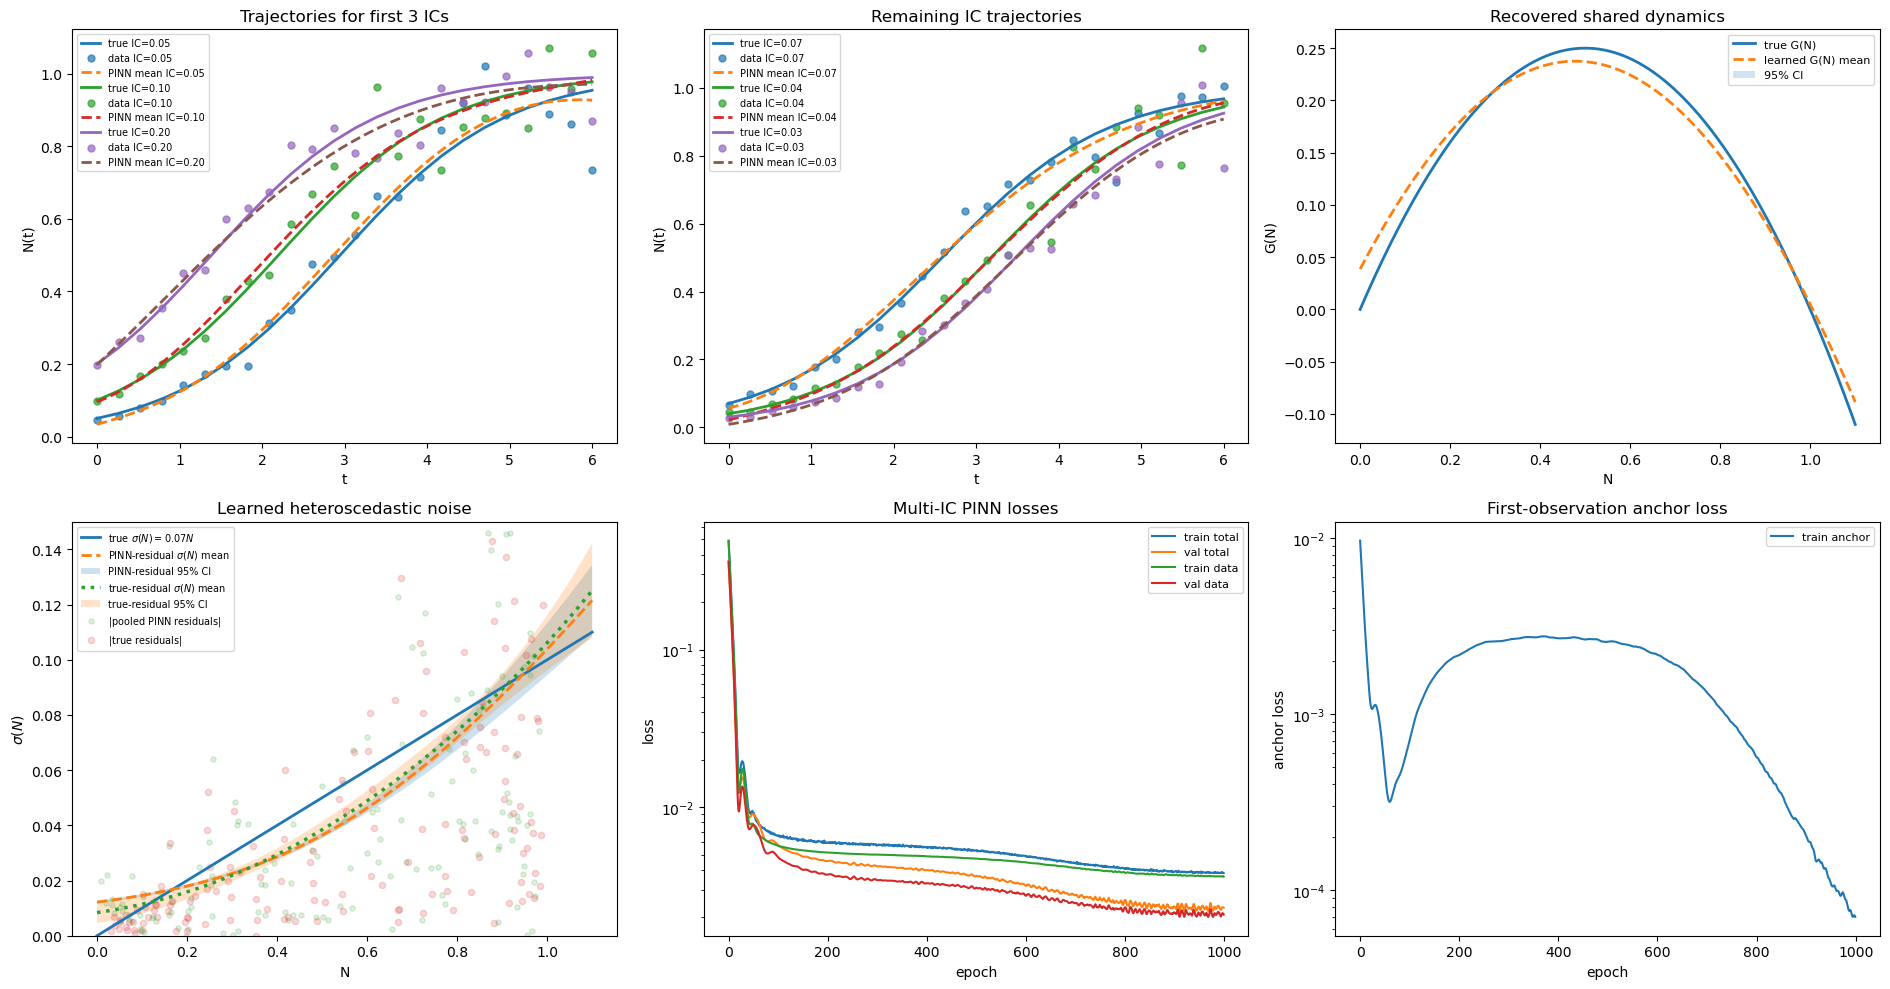

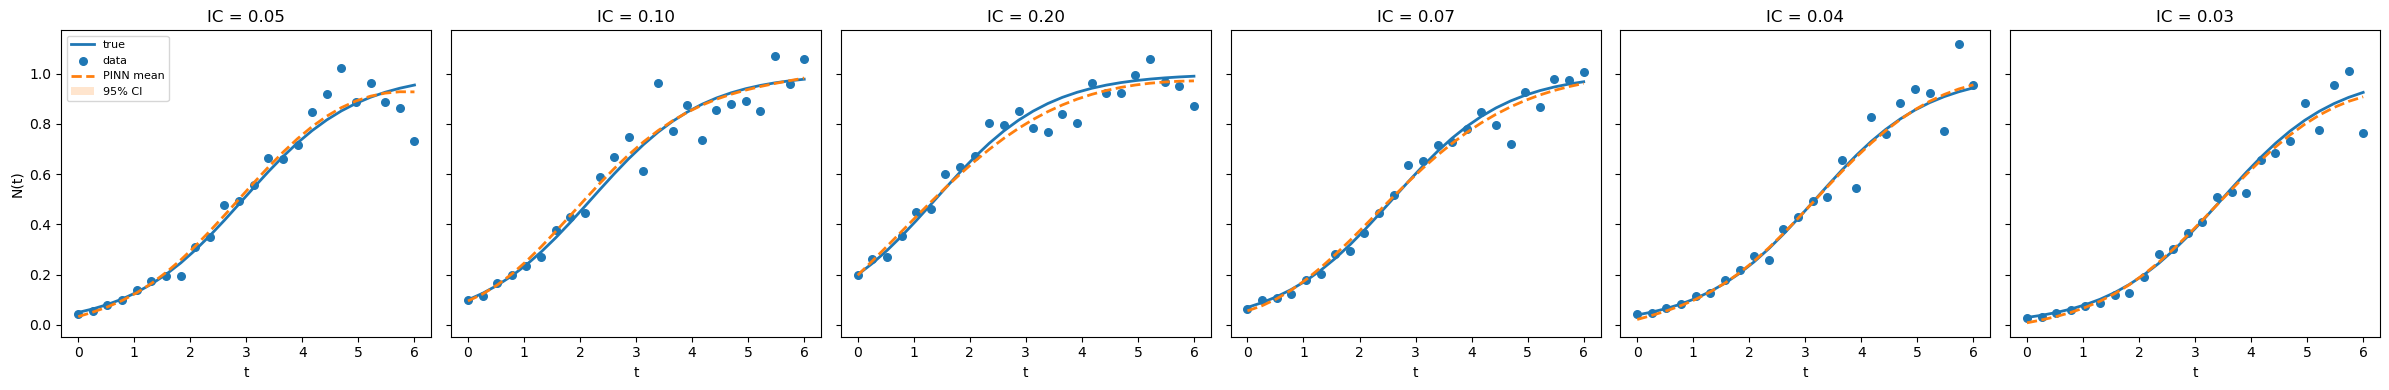

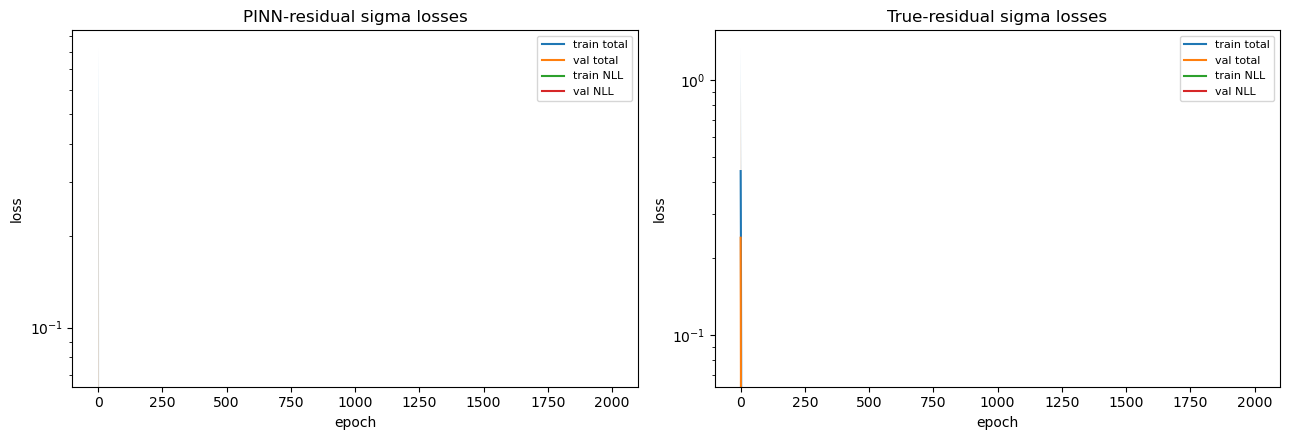

/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/envs/ML4/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Multi-IC PINN summary
---------------------
Number of trajectories / ICs: 6
Synthetic IC values used to generate data: [0.05, 0.1, 0.2, 0.07, 0.04, 0.03]
Number of PINN splits: 1
Mean best validation loss: 2.183213e-03
Std  best validation loss: nan
Mean best epoch: 910.00
Std  best epoch: nan
Anchor weight lambda_anchor: 0.000

Initialization summary by split
-------------------------------
Split 1: dyn_init_seed=10000, sol_init_seeds=[20000, 20001, 20002, 20003, 20004, 20005]

PINN-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -5.321136e+00
Std  best validation loss: 1.588032e-01
Mean best epoch: 1120.40
Std  best epoch: 794.32

True-residual sigma summary
---------------------------
Number of sigma repeats: 5
Mean best validation loss: -5.626998e+00
Std  best validation loss: 2.927534e-01
Mean best epoch: 1111.20
Std  best epoch: 800.03

Observed time points: true vs data vs PINN mean

Trajectory 1 (synthetic IC used to gen

In [3]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.0
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)
t_plot = torch.linspace(0.0, 6.0, 200, device=device).view(-1, 1)
N_grid = torch.linspace(0.0, 1.1, 200, device=device).view(-1, 1)


def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data for multiple ICs
#    Noise law is heteroscedastic: sigma_true(N) = 0.07 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)


y_true_list = []
y_data_list = []

with torch.no_grad():
    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true

        y_true_list.append(y_true)
        y_data_list.append(y_data)

y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, numpts, 1]
y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, numpts, 1]

with torch.no_grad():
    G_grid_true = G_true(N_grid)
    sigma_true_grid = 0.1 * N_grid


# ============================================================
# 3. Model classes
# ============================================================
def init_weights_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        nn.init.zeros_(m.bias)
        
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )
        self.apply(init_weights_xavier)

    def forward(self, N):
        return self.net(N)


class SigmaNet(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
            nn.Softplus(),
        )

    def forward(self, N):
        return self.net(N) + 1e-4


# ============================================================
# 4. Helper functions
# ============================================================
def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


def pinn_physics_residual(sol_net, dyn_net, t_col):
    N_pred_col = sol_net(t_col)
    dN_dt = torch.autograd.grad(
        outputs=N_pred_col,
        inputs=t_col,
        grad_outputs=torch.ones_like(N_pred_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    rhs_pred = dyn_net(N_pred_col)
    phys_res = dN_dt - rhs_pred
    return N_pred_col, dN_dt, rhs_pred, phys_res


def gaussian_sigma_nll(resid, sigma):
    sigma2 = sigma ** 2
    return torch.mean(torch.log(sigma2) + (resid ** 2) / sigma2)


def sigma_monotonicity_loss(model, N_col):
    N_req = N_col.clone().detach().requires_grad_(True)
    sigma_col = model(N_req)
    dsigma_dN = torch.autograd.grad(
        outputs=sigma_col,
        inputs=N_req,
        grad_outputs=torch.ones_like(sigma_col),
        create_graph=True,
        retain_graph=True,
    )[0]
    return torch.sum(torch.relu(-dsigma_dN) ** 2)


def fit_sigma_repeated(
    N_all,
    resid_all,
    N_eval_grid,
    N_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=3000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="sigma",
    print_every=500,
):
    n_samples = N_all.shape[0]
    n_val = int(round(val_fraction * n_samples))
    n_val = max(1, min(n_val, n_samples - 1))
    n_train = n_samples - n_val

    train_total_histories = []
    train_nll_histories = []
    train_mon_histories = []

    val_total_histories = []
    val_nll_histories = []
    val_mon_histories = []

    curve_histories = []
    best_val_losses = []
    best_epochs = []
    best_models = []

    for repeat in range(n_repeats):
        print(f"\n{'-' * 90}")
        print(f"Starting {label} repeat {repeat + 1}/{n_repeats}")
        print(f"{'-' * 90}")

        g = torch.Generator(device=device)
        g.manual_seed(seed_offset_split + repeat)

        perm = torch.randperm(n_samples, generator=g, device=device)
        train_idx = perm[:n_train].sort().values
        val_idx = perm[n_train:].sort().values

        N_train = N_all[train_idx]
        r_train = resid_all[train_idx]
        N_val = N_all[val_idx]
        r_val = resid_all[val_idx]

        torch.manual_seed(seed_offset_model + repeat)
        np.random.seed(seed_offset_model + repeat)

        sigma_net = SigmaNet(hidden_dim=hidden_dim).to(device)
        opt = torch.optim.Adam(sigma_net.parameters(), lr=lr)

        train_total_history = []
        train_nll_history = []
        train_mon_history = []

        val_total_history = []
        val_nll_history = []
        val_mon_history = []

        best_val_loss = float("inf")
        best_epoch = -1
        best_state = None

        

        for epoch in range(n_epochs):
            opt.zero_grad()

            sigma_pred_train = sigma_net(N_train)
            train_nll = gaussian_sigma_nll(r_train, sigma_pred_train)
            train_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            reg = lambda_reg * sum((p ** 2).sum() for p in sigma_net.parameters())

            train_total = train_nll + lambda_mon * train_mon + reg
            train_total.backward()
            opt.step()

            with torch.no_grad():
                sigma_pred_val = sigma_net(N_val)
                val_nll = gaussian_sigma_nll(r_val, sigma_pred_val)

            val_mon = sigma_monotonicity_loss(sigma_net, N_col_base)
            val_total = val_nll + lambda_mon * val_mon

            train_total_history.append(train_total.item())
            train_nll_history.append(train_nll.item())
            train_mon_history.append(train_mon.item())

            val_total_history.append(val_total.item())
            val_nll_history.append(val_nll.item())
            val_mon_history.append(val_mon.item())

            if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
                print(
                    f"{label} | Repeat {repeat + 1:2d}/{n_repeats} | "
                    f"Epoch {epoch + 1:5d}/{n_epochs} | "
                    f"Train Total: {train_total.item():.6e} | "
                    f"Train NLL: {train_nll.item():.6e} | "
                    f"Train Mon: {train_mon.item():.6e} | "
                    f"Val Total: {val_total.item():.6e} | "
                    f"Val NLL: {val_nll.item():.6e} | "
                    f"Val Mon: {val_mon.item():.6e}"
                )

            if val_total.item() < best_val_loss:
                best_val_loss = val_total.item()
                best_epoch = epoch
                best_state = copy.deepcopy(sigma_net.state_dict())

        sigma_net.load_state_dict(best_state)
        sigma_net.eval()

        with torch.no_grad():
            sigma_curve = sigma_net(N_eval_grid).squeeze(1).cpu().numpy()

        best_models.append(copy.deepcopy(sigma_net))
        train_total_histories.append(train_total_history)
        train_nll_histories.append(train_nll_history)
        train_mon_histories.append(train_mon_history)

        val_total_histories.append(val_total_history)
        val_nll_histories.append(val_nll_history)
        val_mon_histories.append(val_mon_history)

        curve_histories.append(sigma_curve)
        best_val_losses.append(best_val_loss)
        best_epochs.append(best_epoch)

        print(
            f"Finished {label} repeat {repeat + 1:2d}/{n_repeats} | "
            f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
        )

    return {
        "train_total_histories": np.array(train_total_histories),
        "train_nll_histories": np.array(train_nll_histories),
        "train_mon_histories": np.array(train_mon_histories),
        "val_total_histories": np.array(val_total_histories),
        "val_nll_histories": np.array(val_nll_histories),
        "val_mon_histories": np.array(val_mon_histories),
        "curve_histories": np.array(curve_histories),
        "best_val_losses": np.array(best_val_losses),
        "best_epochs": np.array(best_epochs),
        "best_models": best_models,
    }


# ============================================================
# 5. Multi-IC PINN fit across train/validation splits
#    - one shared dyn_net
#    - one sol_net per IC
#    - NO true IC penalty
#    - optional anchor to first observed point
#    - DIVERSE NN INITIALIZATIONS across splits and ICs
# ============================================================
n_col = 1000
t_col_base = torch.linspace(0.0, 6.0, n_col, device=device).view(-1, 1)

n_epochs = 1000
n_splits = 1
print_every = 500
batch_obs = 24*4*n_ics
batch_col = 100

val_fraction = 0.2
n_obs = t_obs.shape[0]
n_val = int(round(val_fraction * n_obs))
n_val = max(1, min(n_val, n_obs - 1))
n_train = n_obs - n_val

lambda_phys = 1.0
lambda_anchor = 0.0
learning_rate = 1e-3
hidden_dim_sol = 32
hidden_dim_dyn = 32

# seeds controlling diverse initializations
data_split_seed_base = 1000
dyn_init_seed_base = 10000
sol_init_seed_base = 20000

train_total_histories = []
train_data_histories = []
train_phys_histories = []
train_anchor_histories = []

val_total_histories = []
val_data_histories = []
val_phys_histories = []

traj_histories = []
rhs_histories = []
obs_fit_histories = []

best_val_losses = []
best_epochs = []
best_states = []

for split in range(n_splits):
    print(f"\n{'=' * 90}")
    print(f"Starting PINN split {split + 1}/{n_splits}")
    print(f"{'=' * 90}")

    # -------------------------
    # split-specific data split
    # -------------------------
    g = torch.Generator(device=device)
    g.manual_seed(data_split_seed_base + split)

    perm = torch.randperm(n_obs, generator=g, device=device)
    train_idx = perm[:n_train].sort().values
    val_idx = perm[n_train:].sort().values

    # -------------------------
    # DIVERSE model initialization
    # - different dyn_net init per split
    # - different sol_net init per split
    # - different sol_net init across ICs
    # -------------------------
    torch.manual_seed(dyn_init_seed_base + split)
    np.random.seed(dyn_init_seed_base + split)
    dyn_net = DynamicsNet(hidden_dim=hidden_dim_dyn).to(device)

    sol_net_list = []
    sol_init_seeds_this_split = []
    for i in range(n_ics):
        init_seed = sol_init_seed_base + 1000 * split + i
        sol_init_seeds_this_split.append(init_seed)
        torch.manual_seed(init_seed)
        np.random.seed(init_seed)
        sol_net_list.append(SolutionNet(hidden_dim=hidden_dim_sol).to(device))

    sol_nets = nn.ModuleList(sol_net_list)

    print(f"Dynamics init seed for split {split + 1}: {dyn_init_seed_base + split}")
    print(f"Solution init seeds for split {split + 1}: {sol_init_seeds_this_split}")

    optimizer = torch.optim.Adam(
        list(dyn_net.parameters()) + list(sol_nets.parameters()),
        lr=learning_rate,
    )

    train_total_history = []
    train_data_history = []
    train_phys_history = []
    train_anchor_history = []

    val_total_history = []
    val_data_history = []
    val_phys_history = []

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None


    for epoch in range(n_epochs):
        optimizer.zero_grad()

        total_data_loss = 0.0
        total_phys_loss = 0.0
        total_anchor_loss = 0.0

        for i in range(n_ics):
            sol_net = sol_nets[i]

            # sample observation mini-batch from training indices
            obs_sel = train_idx[torch.randperm(len(train_idx), device=device)[:batch_obs]]
            t_train = t_obs[obs_sel]
            y_train = y_data_all[i][obs_sel]

            N_pred_train = sol_net(t_train)
            data_loss = torch.mean((N_pred_train - y_train) ** 2)

            # resample collocation points each epoch
            t_col = 6.0 * torch.rand(batch_col, 1, device=device)
            t_col.requires_grad_(True)
            _, _, _, phys_res = pinn_physics_residual(sol_net, dyn_net, t_col)
            phys_loss = torch.mean(phys_res ** 2)

            # anchor stays deterministic
            t0_obs = t_obs[0:1]
            y0_obs = y_data_all[i][0:1]
            N0_pred = sol_net(t0_obs)
            anchor_loss = torch.mean((N0_pred - y0_obs) ** 2)

            total_data_loss += data_loss
            total_phys_loss += phys_loss
            total_anchor_loss += anchor_loss

        total_data_loss /= n_ics
        total_phys_loss /= n_ics
        total_anchor_loss /= n_ics

        train_loss = total_data_loss + lambda_phys * total_phys_loss + lambda_anchor * total_anchor_loss
        train_loss.backward()
        optimizer.step()

        with torch.no_grad():
            total_val_data_loss = 0.0
            for i in range(n_ics):
                sol_net = sol_nets[i]
                t_val = t_obs[val_idx]
                y_val = y_data_all[i][val_idx]
                N_pred_val = sol_net(t_val)
                total_val_data_loss = total_val_data_loss + torch.mean((N_pred_val - y_val) ** 2)

            total_val_data_loss = total_val_data_loss / n_ics

        total_val_phys_loss = 0.0
        for i in range(n_ics):
            sol_net = sol_nets[i]
            t_col_val = t_col_base.clone().detach().requires_grad_(True)
            _, _, _, val_phys_res = pinn_physics_residual(sol_net, dyn_net, t_col_val)
            total_val_phys_loss = total_val_phys_loss + torch.mean(val_phys_res ** 2)

        total_val_phys_loss = total_val_phys_loss / n_ics
        val_loss = total_val_data_loss + lambda_phys * total_val_phys_loss

        train_total_history.append(train_loss.item())
        train_data_history.append(total_data_loss.item())
        train_phys_history.append(total_phys_loss.item())
        train_anchor_history.append(total_anchor_loss.item())

        val_total_history.append(val_loss.item())
        val_data_history.append(total_val_data_loss.item())
        val_phys_history.append(total_val_phys_loss.item())

        if (epoch == 0) or ((epoch + 1) % print_every == 0) or (epoch == n_epochs - 1):
            print(
                f"PINN | Split {split + 1:2d}/{n_splits} | "
                f"Epoch {epoch + 1:5d}/{n_epochs} | "
                f"Train Total: {train_loss.item():.6e} | "
                f"Train Data: {total_data_loss.item():.6e} | "
                f"Train Phys: {total_phys_loss.item():.6e} | "
                f"Train Anchor: {total_anchor_loss.item():.6e} | "
                f"Val Total: {val_loss.item():.6e} | "
                f"Val Data: {total_val_data_loss.item():.6e} | "
                f"Val Phys: {total_val_phys_loss.item():.6e}"
            )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                "dyn_net": copy.deepcopy(dyn_net.state_dict()),
                "sol_nets": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn_init_seed": dyn_init_seed_base + split,
                "sol_init_seeds": sol_init_seeds_this_split.copy(),
                "train_idx": train_idx.clone(),
                "val_idx": val_idx.clone(),
            }

    print(
        f"Finished PINN split {split + 1:2d}/{n_splits} | "
        f"Best epoch = {best_epoch:5d} | Best val loss = {best_val_loss:.6e}"
    )

    dyn_net.load_state_dict(best_state["dyn_net"])
    for i in range(n_ics):
        sol_nets[i].load_state_dict(best_state["sol_nets"][i])

    dyn_net.eval()
    for sol_net in sol_nets:
        sol_net.eval()

    with torch.no_grad():
        trajs_this_split = []
        obs_fits_this_split = []

        for i in range(n_ics):
            trajs_this_split.append(sol_nets[i](t_plot).squeeze(1).cpu().numpy())
            obs_fits_this_split.append(sol_nets[i](t_obs).squeeze(1).cpu().numpy())

        G_grid_learned = dyn_net(N_grid).squeeze(1).cpu().numpy()

    train_total_histories.append(train_total_history)
    train_data_histories.append(train_data_history)
    train_phys_histories.append(train_phys_history)
    train_anchor_histories.append(train_anchor_history)

    val_total_histories.append(val_total_history)
    val_data_histories.append(val_data_history)
    val_phys_histories.append(val_phys_history)

    traj_histories.append(np.array(trajs_this_split))
    obs_fit_histories.append(np.array(obs_fits_this_split))
    rhs_histories.append(G_grid_learned)

    best_val_losses.append(best_val_loss)
    best_epochs.append(best_epoch)
    best_states.append(best_state)

train_total_histories = np.array(train_total_histories)
train_data_histories = np.array(train_data_histories)
train_phys_histories = np.array(train_phys_histories)
train_anchor_histories = np.array(train_anchor_histories)

val_total_histories = np.array(val_total_histories)
val_data_histories = np.array(val_data_histories)
val_phys_histories = np.array(val_phys_histories)

traj_histories = np.array(traj_histories)         # [n_splits, n_ics, len(t_plot)]
obs_fit_histories = np.array(obs_fit_histories)   # [n_splits, n_ics, len(t_obs)]
rhs_histories = np.array(rhs_histories)

rhs_mean, rhs_lo, rhs_hi = mean_and_ci(rhs_histories)

traj_mean_per_ic = []
traj_lo_per_ic = []
traj_hi_per_ic = []

obs_fit_mean_per_ic = []
obs_fit_lo_per_ic = []
obs_fit_hi_per_ic = []

for i in range(n_ics):
    m, lo, hi = mean_and_ci(traj_histories[:, i, :])
    traj_mean_per_ic.append(m)
    traj_lo_per_ic.append(lo)
    traj_hi_per_ic.append(hi)

    m, lo, hi = mean_and_ci(obs_fit_histories[:, i, :])
    obs_fit_mean_per_ic.append(m)
    obs_fit_lo_per_ic.append(lo)
    obs_fit_hi_per_ic.append(hi)


# ============================================================
# 6. Learn sigma(N) from pooled multi-IC PINN residuals
#    residual = y_data - N_hat_PINN
# ============================================================
with torch.no_grad():
    y_rep = y_data_all.squeeze(-1).cpu().numpy()[None, :, :]
    resid_pinn_all_np = y_rep - obs_fit_histories

    N_pinn_sigma_all_np = obs_fit_histories.reshape(-1, 1)
    resid_pinn_sigma_all_np = resid_pinn_all_np.reshape(-1, 1)

    mask = N_pinn_sigma_all_np.squeeze() > 0.0
    N_pinn_sigma_all_np = N_pinn_sigma_all_np[mask]
    resid_pinn_sigma_all_np = resid_pinn_sigma_all_np[mask]

N_pinn_sigma_all = torch.tensor(N_pinn_sigma_all_np, dtype=torch.float32, device=device)
resid_pinn_sigma_all = torch.tensor(resid_pinn_sigma_all_np, dtype=torch.float32, device=device)

N_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_pinn_sigma_all.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_pinn_results = fit_sigma_repeated(
    N_all=N_pinn_sigma_all,
    resid_all=resid_pinn_sigma_all,
    N_eval_grid=N_grid,
    N_col_base=N_sigma_col_base,
    n_repeats=5,
    val_fraction=0.4,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=5000,
    seed_offset_model=7000,
    label="PINN-sigma",
    print_every=250,
)

sigma_pinn_mean, sigma_pinn_lo, sigma_pinn_hi = mean_and_ci(
    sigma_pinn_results["curve_histories"]
)


# ============================================================
# 7. Learn sigma_truefit(N) from true residuals using all ICs
#    residual_true = y_data - y_true
# ============================================================
with torch.no_grad():
    N_true_sigma_np = y_true_all.squeeze(-1).cpu().numpy().reshape(-1, 1)
    resid_true_sigma_np = (y_data_all - y_true_all).squeeze(-1).cpu().numpy().reshape(-1, 1)

    mask_true = N_true_sigma_np.squeeze() > 0.0
    N_true_sigma_np = N_true_sigma_np[mask_true]
    resid_true_sigma_np = resid_true_sigma_np[mask_true]

N_true_sigma = torch.tensor(N_true_sigma_np, dtype=torch.float32, device=device)
resid_true_sigma = torch.tensor(resid_true_sigma_np, dtype=torch.float32, device=device)

N_true_sigma_col_base = torch.linspace(
    0.0,
    max(1.1, float(N_true_sigma.max().item())),
    200,
    device=device,
).view(-1, 1)

sigma_truefit_results = fit_sigma_repeated(
    N_all=N_true_sigma,
    resid_all=resid_true_sigma,
    N_eval_grid=N_grid,
    N_col_base=N_true_sigma_col_base,
    n_repeats=5,
    val_fraction=0.2,
    n_epochs=2000,
    lr=5e-3,
    hidden_dim=8,
    lambda_mon=1.0,
    lambda_reg=1e-5,
    seed_offset_split=9000,
    seed_offset_model=11000,
    label="TRUE-sigma",
    print_every=250,
)

sigma_truefit_mean, sigma_truefit_lo, sigma_truefit_hi = mean_and_ci(
    sigma_truefit_results["curve_histories"]
)


# ============================================================
# 8. Residuals across all ICs using mean PINN fit
# ============================================================
with torch.no_grad():
    obs_fit_mean_all = np.array(obs_fit_mean_per_ic)
    y_true_np = y_true_all.squeeze(-1).cpu().numpy()
    y_data_np = y_data_all.squeeze(-1).cpu().numpy()

    residuals_all = y_data_np - obs_fit_mean_all
    N_fit_all = obs_fit_mean_all.reshape(-1, 1)
    residuals_flat = residuals_all.reshape(-1, 1)

    mask = N_fit_all.squeeze() > 0.0
    N_fit_all = N_fit_all[mask]
    residuals_flat = residuals_flat[mask]


# ============================================================
# 9. Plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# ------------------------------------------------------------
# Trajectories for first 3 ICs
# ------------------------------------------------------------
for i in range(min(3, n_ics)):
    axes[0, 0].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 0].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 0].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 0].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 0].set_xlabel("t")
axes[0, 0].set_ylabel("N(t)")
axes[0, 0].set_title("Trajectories for first 3 ICs")
axes[0, 0].legend(fontsize=7)

# ------------------------------------------------------------
# Trajectories for remaining ICs
# ------------------------------------------------------------
for i in range(3, n_ics):
    axes[0, 1].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        linewidth=2,
        label=f"true IC={N0_list[i]:.2f}",
    )
    axes[0, 1].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        s=25,
        alpha=0.7,
        label=f"data IC={N0_list[i]:.2f}",
    )
    axes[0, 1].plot(
        t_plot.cpu().numpy(),
        traj_mean_per_ic[i],
        "--",
        linewidth=2,
        label=f"PINN mean IC={N0_list[i]:.2f}",
    )
    axes[0, 1].fill_between(
        t_plot.squeeze(1).cpu().numpy(),
        traj_lo_per_ic[i],
        traj_hi_per_ic[i],
        alpha=0.18,
    )

axes[0, 1].set_xlabel("t")
axes[0, 1].set_ylabel("N(t)")
axes[0, 1].set_title("Remaining IC trajectories")
axes[0, 1].legend(fontsize=7)

# ------------------------------------------------------------
# Recovered dynamics
# ------------------------------------------------------------
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    G_grid_true.squeeze(1).cpu().numpy(),
    label="true G(N)",
    linewidth=2,
)
axes[0, 2].plot(
    N_grid.cpu().numpy(),
    rhs_mean,
    "--",
    linewidth=2,
    label="learned G(N) mean",
)
axes[0, 2].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    rhs_lo,
    rhs_hi,
    alpha=0.20,
    label="95% CI",
)
axes[0, 2].set_xlabel("N")
axes[0, 2].set_ylabel("G(N)")
axes[0, 2].set_title("Recovered shared dynamics")
axes[0, 2].legend(fontsize=8)

# ------------------------------------------------------------
# Learned sigma(N): PINN residual sigma + true residual sigma
# ------------------------------------------------------------
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.07N$",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
axes[1, 0].plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
axes[1, 0].fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
axes[1, 0].scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
axes[1, 0].scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
axes[1, 0].set_xlabel("N")
axes[1, 0].set_ylabel(r"$\sigma(N)$")
axes[1, 0].set_title("Learned heteroscedastic noise")
axes[1, 0].legend(fontsize=7)
axes[1, 0].set_ylim(0, 0.15)

# ------------------------------------------------------------
# PINN training losses
# ------------------------------------------------------------
epochs_init = np.arange(n_epochs)

train_total_mean, train_total_lo, train_total_hi = mean_and_ci(train_total_histories)
val_total_mean, val_total_lo, val_total_hi = mean_and_ci(val_total_histories)
train_data_mean, train_data_lo, train_data_hi = mean_and_ci(train_data_histories)
val_data_mean, val_data_lo, val_data_hi = mean_and_ci(val_data_histories)

axes[1, 1].plot(epochs_init, train_total_mean, label="train total")
axes[1, 1].fill_between(epochs_init, train_total_lo, train_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_total_mean, label="val total")
axes[1, 1].fill_between(epochs_init, val_total_lo, val_total_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, train_data_mean, label="train data")
axes[1, 1].fill_between(epochs_init, train_data_lo, train_data_hi, alpha=0.2)
axes[1, 1].plot(epochs_init, val_data_mean, label="val data")
axes[1, 1].fill_between(epochs_init, val_data_lo, val_data_hi, alpha=0.2)
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("epoch")
axes[1, 1].set_ylabel("loss")
axes[1, 1].set_title("Multi-IC PINN losses")
axes[1, 1].legend(fontsize=8)

# ------------------------------------------------------------
# Anchor loss
# ------------------------------------------------------------
train_anchor_mean, train_anchor_lo, train_anchor_hi = mean_and_ci(train_anchor_histories)
axes[1, 2].plot(epochs_init, train_anchor_mean, label="train anchor")
axes[1, 2].fill_between(epochs_init, train_anchor_lo, train_anchor_hi, alpha=0.2)
axes[1, 2].set_yscale("log")
axes[1, 2].set_xlabel("epoch")
axes[1, 2].set_ylabel("anchor loss")
axes[1, 2].set_title("First-observation anchor loss")
axes[1, 2].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 10. Observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_obs.cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        label="data",
        s=30,
    )
    axs[i].plot(
        t_obs.cpu().numpy(),
        obs_fit_mean_per_ic[i],
        "--",
        linewidth=2,
        label="PINN mean",
    )
    axs[i].fill_between(
        t_obs.squeeze(1).cpu().numpy(),
        obs_fit_lo_per_ic[i],
        obs_fit_hi_per_ic[i],
        alpha=0.20,
        label="95% CI",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


# ============================================================
# 11. Sigma training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

epochs_sigma = np.arange(sigma_pinn_results["train_total_histories"].shape[1])

sp_train_total_mean, sp_train_total_lo, sp_train_total_hi = mean_and_ci(
    sigma_pinn_results["train_total_histories"]
)
sp_val_total_mean, sp_val_total_lo, sp_val_total_hi = mean_and_ci(
    sigma_pinn_results["val_total_histories"]
)
sp_train_nll_mean, sp_train_nll_lo, sp_train_nll_hi = mean_and_ci(
    sigma_pinn_results["train_nll_histories"]
)
sp_val_nll_mean, sp_val_nll_lo, sp_val_nll_hi = mean_and_ci(
    sigma_pinn_results["val_nll_histories"]
)

axes[0].plot(epochs_sigma, sp_train_total_mean, label="train total")
axes[0].fill_between(epochs_sigma, sp_train_total_lo, sp_train_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_total_mean, label="val total")
axes[0].fill_between(epochs_sigma, sp_val_total_lo, sp_val_total_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_train_nll_mean, label="train NLL")
axes[0].fill_between(epochs_sigma, sp_train_nll_lo, sp_train_nll_hi, alpha=0.2)
axes[0].plot(epochs_sigma, sp_val_nll_mean, label="val NLL")
axes[0].fill_between(epochs_sigma, sp_val_nll_lo, sp_val_nll_hi, alpha=0.2)
axes[0].set_yscale("log")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("PINN-residual sigma losses")
axes[0].legend(fontsize=8)

st_train_total_mean, st_train_total_lo, st_train_total_hi = mean_and_ci(
    sigma_truefit_results["train_total_histories"]
)
st_val_total_mean, st_val_total_lo, st_val_total_hi = mean_and_ci(
    sigma_truefit_results["val_total_histories"]
)
st_train_nll_mean, st_train_nll_lo, st_train_nll_hi = mean_and_ci(
    sigma_truefit_results["train_nll_histories"]
)
st_val_nll_mean, st_val_nll_lo, st_val_nll_hi = mean_and_ci(
    sigma_truefit_results["val_nll_histories"]
)

axes[1].plot(epochs_sigma, st_train_total_mean, label="train total")
axes[1].fill_between(epochs_sigma, st_train_total_lo, st_train_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_total_mean, label="val total")
axes[1].fill_between(epochs_sigma, st_val_total_lo, st_val_total_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_train_nll_mean, label="train NLL")
axes[1].fill_between(epochs_sigma, st_train_nll_lo, st_train_nll_hi, alpha=0.2)
axes[1].plot(epochs_sigma, st_val_nll_mean, label="val NLL")
axes[1].fill_between(epochs_sigma, st_val_nll_lo, st_val_nll_hi, alpha=0.2)
axes[1].set_yscale("log")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("loss")
axes[1].set_title("True-residual sigma losses")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


# ============================================================
# 12. Summary
# ============================================================
print("\nMulti-IC PINN summary")
print("---------------------")
print(f"Number of trajectories / ICs: {n_ics}")
print(f"Synthetic IC values used to generate data: {N0_list}")
print(f"Number of PINN splits: {n_splits}")
print(f"Mean best validation loss: {np.mean(best_val_losses):.6e}")
print(f"Std  best validation loss: {np.std(best_val_losses, ddof=1):.6e}")
print(f"Mean best epoch: {np.mean(best_epochs):.2f}")
print(f"Std  best epoch: {np.std(best_epochs, ddof=1):.2f}")
print(f"Anchor weight lambda_anchor: {lambda_anchor:.3f}")

print("\nInitialization summary by split")
print("-------------------------------")
for split, st in enumerate(best_states, start=1):
    print(
        f"Split {split}: dyn_init_seed={st['dyn_init_seed']}, "
        f"sol_init_seeds={st['sol_init_seeds']}"
    )

print("\nPINN-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_pinn_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_pinn_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_pinn_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_pinn_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_pinn_results['best_epochs'].std(ddof=1):.2f}")

print("\nTrue-residual sigma summary")
print("---------------------------")
print(f"Number of sigma repeats: {len(sigma_truefit_results['best_val_losses'])}")
print(f"Mean best validation loss: {sigma_truefit_results['best_val_losses'].mean():.6e}")
print(f"Std  best validation loss: {sigma_truefit_results['best_val_losses'].std(ddof=1):.6e}")
print(f"Mean best epoch: {sigma_truefit_results['best_epochs'].mean():.2f}")
print(f"Std  best epoch: {sigma_truefit_results['best_epochs'].std(ddof=1):.2f}")

print("\nObserved time points: true vs data vs PINN mean")
for i in range(n_ics):
    print(f"\nTrajectory {i + 1} (synthetic IC used to generate data = {N0_list[i]:.2f})")
    for ti, yt, yd, mu in zip(
        t_obs.squeeze(1).cpu().numpy(),
        y_true_all[i].squeeze(1).cpu().numpy(),
        y_data_all[i].squeeze(1).cpu().numpy(),
        obs_fit_mean_per_ic[i],
    ):
        print(
            f"t = {ti:6.3f} | true = {yt:8.5f} | data = {yd:8.5f} | PINN = {mu:8.5f}"
        )

[MAP] ep=    1/2000 | total=3.2447e+01 | data=3.2212e+01 | phys=1.3763e-01 | prior=9.7511e-02
[MAP] ep=  500/2000 | total=3.4137e-01 | data=2.4798e-01 | phys=1.2642e-02 | prior=8.0750e-02
[MAP] ep= 1000/2000 | total=2.9521e-01 | data=2.2370e-01 | phys=9.7945e-03 | prior=6.1723e-02
[MAP] ep= 1500/2000 | total=2.8085e-01 | data=2.2022e-01 | phys=9.4225e-03 | prior=5.1209e-02
[MAP] ep= 2000/2000 | total=2.7271e-01 | data=2.1889e-01 | phys=9.3825e-03 | prior=4.4435e-02

Training rPINN sample 1/10

Training rPINN sample 2/10

Training rPINN sample 3/10

Training rPINN sample 4/10

Training rPINN sample 5/10

Training rPINN sample 6/10

Training rPINN sample 7/10

Training rPINN sample 8/10

Training rPINN sample 9/10

Training rPINN sample 10/10

================ Summary ================
Number of ICs                : 6
MAP best loss                : 2.727055e-01
Mean rPINN best loss         : 1.265059e+00
State posterior RMSE         : 1.548533e-02
G posterior mean rel L2 error: 6.660425e-

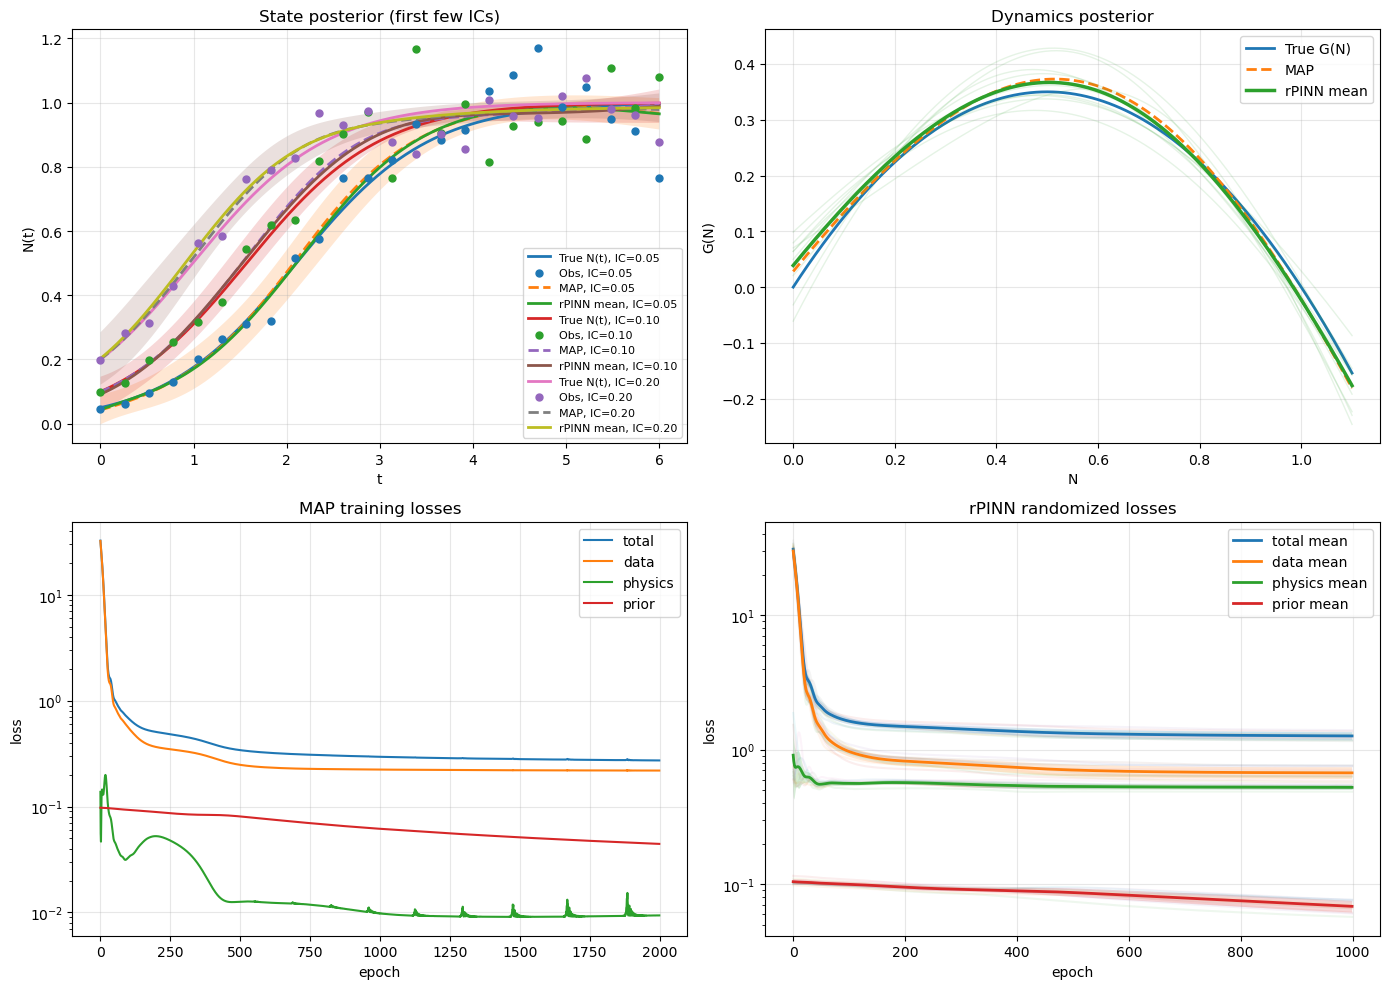

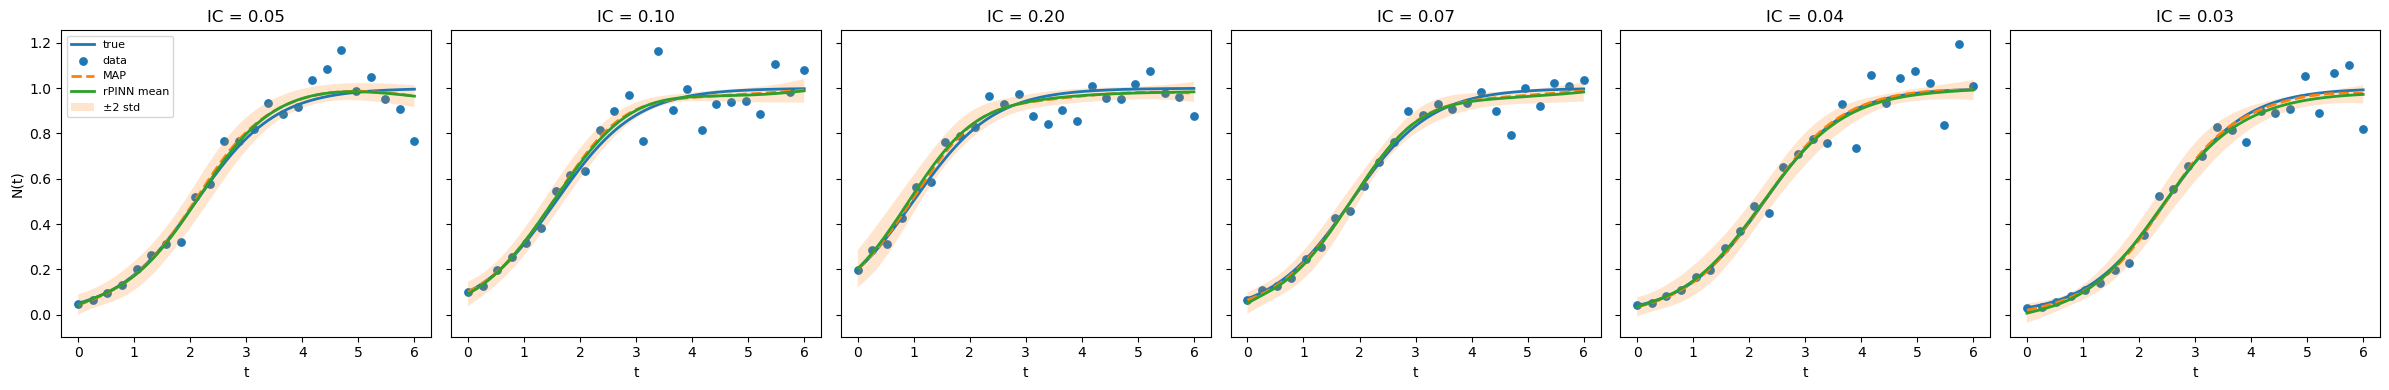

In [67]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0_list = [0.05, 0.10, 0.20, 0.07, 0.04, 0.03]
n_ics = len(N0_list)

numpts = 4 * (24 // 4)
t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y_true_list = []
    y_data_list = []

    for N0 in N0_list:
        y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
        y_true_i = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)
        y_data_i = y_true_i + 0.1 * torch.randn_like(y_true_i) * y_true_i

        y_true_list.append(y_true_i)
        y_data_list.append(y_data_i)

    y_true_all = torch.stack(y_true_list, dim=0)   # [n_ics, T, 1]
    y_data_all = torch.stack(y_data_list, dim=0)   # [n_ics, T, 1]


# ============================================================
# 3. Networks
# ============================================================
class SolutionNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, t):
        return self.net(t)


class DynamicsNet(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, N):
        return self.net(N)


# ============================================================
# 4. Helpers
# ============================================================
def make_sigma_data_from_obs(y_obs, floor=0.02):
    """
    Known heteroscedastic observation model.
    Here we use sigma(y_obs)=0.1*|y_obs| with a small floor.
    Works for either [T,1] or [n_ics,T,1] tensors.
    """
    return 0.1 * torch.ones_like(y_obs) 
    #return 0.1 * torch.clamp(y_obs.abs(), min=floor)

def flatten_param_count(model):
    return sum(p.numel() for p in model.parameters())

def l2_prior_loss(model, sigma_prior):
    loss = 0.0
    nblocks = 0
    for p in model.parameters():
        loss = loss + 0.5 * torch.mean((p / sigma_prior) ** 2)
        nblocks += 1
    return loss / nblocks

def randomized_prior_loss(model, noise_list, sigma_prior):
    loss = 0.0
    nblocks = 0
    for p, eta in zip(model.parameters(), noise_list):
        loss = loss + 0.5 * torch.mean((p / sigma_prior - eta) ** 2)
        nblocks += 1
    return loss / nblocks

def grad_wrt_t(y, t):
    return torch.autograd.grad(
        outputs=y,
        inputs=t,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]

def mean_and_std(arr, axis=0):
    arr = np.array(arr)
    return arr.mean(axis=axis), arr.std(axis=axis)

def mean_and_ci(arr, ci=1.96):
    arr = np.array(arr)
    mean = arr.mean(axis=0)
    if arr.shape[0] == 1:
        lo = mean.copy()
        hi = mean.copy()
    else:
        sem = arr.std(axis=0, ddof=1) / np.sqrt(arr.shape[0])
        lo = mean - ci * sem
        hi = mean + ci * sem
    return mean, lo, hi


# ============================================================
# 5. Bayesian/MAP and randomized rPINN losses
# ============================================================
t_phys = torch.linspace(0.0, 6.0, 300, device=device).view(-1, 1)

# Known observation uncertainty model from data
sigma_data_all = make_sigma_data_from_obs(y_data_all)

# Hyperparameters
sigma_phys = 0.1
sigma_prior = 1

def compute_map_losses(sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys,
                       sigma_phys=0.05, sigma_prior=1.0):
    """
    Deterministic multi-IC PINN/MAP objective:
      average over ICs of:
        data term + physics term
      plus Gaussian priors
    No true-IC term is used.
    """
    total_data_loss = 0.0
    total_physics_loss = 0.0

    for i, sol_net in enumerate(sol_nets):
        # ----- data term -----
        N_obs = sol_net(t_obs)
        data_res = (N_obs - y_data_all[i]) / sigma_data_all[i]
        data_loss_i = 0.5 * torch.mean(data_res ** 2)

        # ----- physics term -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = grad_wrt_t(N_phys, t_phys_req)
        G_phys = dyn_net(N_phys)
        phys_res = (dN_dt - G_phys) / sigma_phys
        physics_loss_i = 0.5 * torch.mean(phys_res ** 2)

        total_data_loss = total_data_loss + data_loss_i
        total_physics_loss = total_physics_loss + physics_loss_i

    data_loss = total_data_loss / len(sol_nets)
    physics_loss = total_physics_loss / len(sol_nets)

    # ----- Gaussian priors on NN weights -----
    prior_sol = 0.0
    for sol_net in sol_nets:
        prior_sol = prior_sol + l2_prior_loss(sol_net, sigma_prior)
    prior_sol = prior_sol / len(sol_nets)

    prior_dyn = l2_prior_loss(dyn_net, sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss + prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }

def sample_rpinn_noises(sol_nets, dyn_net, y_shape, phys_shape, device):
    """
    In normalized coordinates, all randomized targets are standard normal.
    One data/physics noise per IC, and one prior noise list per network.
    """
    noise = {
        "data": [torch.randn(y_shape, device=device) for _ in range(len(sol_nets))],
        "physics": [torch.randn(phys_shape, device=device) for _ in range(len(sol_nets))],
        "sol_prior": [[torch.randn_like(p)*0 for p in sol_net.parameters()] for sol_net in sol_nets],
        "dyn_prior": [torch.randn_like(p)*0 for p in dyn_net.parameters()],
    }
    return noise

def compute_randomized_losses(sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys, noise,
                              sigma_phys=0.05, sigma_prior=1.0):
    """
    Multi-IC rPINN randomized objective:
      average over ICs of:
        0.5 * || standardized_residual - random_noise ||^2
      for data and physics, plus randomized priors.
    """
    total_data_loss = 0.0
    total_physics_loss = 0.0

    for i, sol_net in enumerate(sol_nets):
        # ----- randomized data term -----
        N_obs = sol_net(t_obs)
        data_res = (N_obs - y_data_all[i]) / sigma_data_all[i]
        data_loss_i = 0.5 * torch.mean((data_res - noise["data"][i]) ** 2)

        # ----- randomized physics term -----
        t_phys_req = t_phys.clone().detach().requires_grad_(True)
        N_phys = sol_net(t_phys_req)
        dN_dt = grad_wrt_t(N_phys, t_phys_req)
        G_phys = dyn_net(N_phys)
        phys_res = (dN_dt - G_phys) / sigma_phys
        physics_loss_i = 0.5 * torch.mean((phys_res - noise["physics"][i]) ** 2)

        total_data_loss = total_data_loss + data_loss_i
        total_physics_loss = total_physics_loss + physics_loss_i

    data_loss = total_data_loss / len(sol_nets)
    physics_loss = total_physics_loss / len(sol_nets)

    # ----- randomized priors -----
    prior_sol = 0.0
    for sol_net, eta_list in zip(sol_nets, noise["sol_prior"]):
        prior_sol = prior_sol + randomized_prior_loss(sol_net, eta_list, sigma_prior)
    prior_sol = prior_sol / len(sol_nets)

    prior_dyn = randomized_prior_loss(dyn_net, noise["dyn_prior"], sigma_prior)
    prior_loss = prior_sol + prior_dyn

    total = data_loss + physics_loss + prior_loss
    return {
        "total": total,
        "data": data_loss,
        "physics": physics_loss,
        "prior": prior_loss,
    }


# ============================================================
# 6. Training utilities
# ============================================================
def train_map_model(sol_nets, dyn_net,
                    t_obs, y_data_all, sigma_data_all, t_phys,
                    lr=1e-3, epochs=4000,
                    sigma_phys=0.05, sigma_prior=1.0,
                    verbose_every=500):
    params = list(dyn_net.parameters())
    for sol_net in sol_nets:
        params += list(sol_net.parameters())

    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_map_losses(
            sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol_list": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose_every is not None and ((ep == 0) or ((ep + 1) % verbose_every == 0) or (ep == epochs - 1)):
            print(
                f"[MAP] ep={ep+1:5d}/{epochs} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}"
            )

    for i, sol_net in enumerate(sol_nets):
        sol_net.load_state_dict(best_state["sol_list"][i])
    dyn_net.load_state_dict(best_state["dyn"])

    return history, best_loss

def train_rpinn_sample(base_sol_states, base_dyn_state,
                       t_obs, y_data_all, sigma_data_all, t_phys,
                       hidden_dim=64, lr=1e-3, epochs=2000,
                       sigma_phys=0.05, sigma_prior=1.0,
                       warmstart_noise=1e-2, verbose=False):
    """
    Train one randomized multi-IC sample, initialized from MAP weights + tiny perturbation.
    """
    sol_nets = nn.ModuleList([SolutionNet(hidden_dim=hidden_dim).to(device) for _ in range(len(base_sol_states))])
    dyn_net = DynamicsNet(hidden_dim=hidden_dim).to(device)

    # for i, sol_net in enumerate(sol_nets):
    #     sol_net.load_state_dict(copy.deepcopy(base_sol_states[i]))
    # dyn_net.load_state_dict(copy.deepcopy(base_dyn_state))

    with torch.no_grad():
        for sol_net in sol_nets:
            for p in sol_net.parameters():
                p.add_(warmstart_noise * torch.randn_like(p))
        for p in dyn_net.parameters():
            p.add_(warmstart_noise * torch.randn_like(p))

    noise = sample_rpinn_noises(
        sol_nets, dyn_net,
        y_shape=y_data_all[0].shape,
        phys_shape=(t_phys.shape[0], 1),
        device=device
    )

    params = list(dyn_net.parameters())
    for sol_net in sol_nets:
        params += list(sol_net.parameters())

    opt = torch.optim.Adam(params, lr=lr)

    history = {"total": [], "data": [], "physics": [], "prior": []}
    best_loss = float("inf")
    best_state = None

    for ep in range(epochs):
        opt.zero_grad()
        losses = compute_randomized_losses(
            sol_nets, dyn_net, t_obs, y_data_all, sigma_data_all, t_phys, noise,
            sigma_phys=sigma_phys, sigma_prior=sigma_prior
        )
        losses["total"].backward()
        opt.step()

        for k in history:
            history[k].append(losses[k].item())

        if losses["total"].item() < best_loss:
            best_loss = losses["total"].item()
            best_state = {
                "sol_list": [copy.deepcopy(sol_net.state_dict()) for sol_net in sol_nets],
                "dyn": copy.deepcopy(dyn_net.state_dict()),
            }

        if verbose and ((ep == 0) or ((ep + 1) % 500 == 0) or (ep == epochs - 1)):
            print(
                f"[rPINN] ep={ep+1:5d}/{epochs} | "
                f"total={losses['total'].item():.4e} | "
                f"data={losses['data'].item():.4e} | "
                f"phys={losses['physics'].item():.4e} | "
                f"prior={losses['prior'].item():.4e}"
            )

    for i, sol_net in enumerate(sol_nets):
        sol_net.load_state_dict(best_state["sol_list"][i])
    dyn_net.load_state_dict(best_state["dyn"])

    return sol_nets, dyn_net, history, best_loss


# ============================================================
# 7. MAP pretraining
# ============================================================
hidden_dim = 32

map_sols = nn.ModuleList([SolutionNet(hidden_dim=hidden_dim).to(device) for _ in range(n_ics)])
map_dyn = DynamicsNet(hidden_dim=hidden_dim).to(device)

map_history, map_best = train_map_model(
    map_sols, map_dyn,
    t_obs, y_data_all, sigma_data_all, t_phys,
    lr=1e-3,
    epochs=2000,
    sigma_phys=sigma_phys,
    sigma_prior=sigma_prior,
    verbose_every=500
)

base_sol_states = [copy.deepcopy(sol_net.state_dict()) for sol_net in map_sols]
base_dyn_state = copy.deepcopy(map_dyn.state_dict())


# ============================================================
# 8. rPINN ensemble
# ============================================================
n_samples = 10
sample_histories = []
sol_samples = []
dyn_samples = []
sample_best_losses = []

for s in range(n_samples):
    print(f"\nTraining rPINN sample {s+1}/{n_samples}")
    sol_s_list, dyn_s, hist_s, best_s = train_rpinn_sample(
        base_sol_states, base_dyn_state,
        t_obs, y_data_all, sigma_data_all, t_phys,
        hidden_dim=hidden_dim,
        lr=1e-3,
        epochs=1000,
        sigma_phys=sigma_phys,
        sigma_prior=sigma_prior,
        warmstart_noise=0,
        verbose=False
    )
    sol_samples.append(sol_s_list)
    dyn_samples.append(dyn_s)
    sample_histories.append(hist_s)
    sample_best_losses.append(best_s)


# ============================================================
# 9. Posterior predictions
# ============================================================
t_plot = torch.linspace(0.0, 6.0, 400, device=device).view(-1, 1)

with torch.no_grad():
    y_true_dense_list = []
    for N0 in N0_list:
        y_true_dense_i = odeint_rk4(
            lambda t, y: G_true(y),
            torch.tensor([[N0]], dtype=torch.float32, device=device),
            t_plot.squeeze()
        ).squeeze(1)
        y_true_dense_list.append(y_true_dense_i)

    y_true_dense_all = torch.stack(y_true_dense_list, dim=0)   # [n_ics, T, 1]

    # State posterior: [S, n_ics, T]
    N_ensemble = []
    for sol_list in sol_samples:
        pred_this_sample = []
        for i in range(n_ics):
            pred_this_sample.append(sol_list[i](t_plot).squeeze(-1))
        N_ensemble.append(torch.stack(pred_this_sample, dim=0).squeeze(-1))
    N_ensemble = torch.stack(N_ensemble, dim=0)

    N_mean = N_ensemble.mean(dim=0)   # [n_ics, T]
    N_std = N_ensemble.std(dim=0)     # [n_ics, T]

    # Dynamics posterior
    ymax = float(torch.max(y_true_dense_all).cpu())
    N_grid = torch.linspace(
        0.0,
        max(1.1, ymax + 0.05),
        300,
        device=device
    ).view(-1, 1)

    G_ensemble = []
    for dyn_s in dyn_samples:
        G_ensemble.append(dyn_s(N_grid).squeeze(-1))
    G_ensemble = torch.stack(G_ensemble, dim=0)   # [S, M]

    G_mean = G_ensemble.mean(dim=0)
    G_std = G_ensemble.std(dim=0)
    G_exact = G_true(N_grid).squeeze(-1)

    # MAP predictions for reference
    N_map_all = []
    for i in range(n_ics):
        N_map_all.append(map_sols[i](t_plot).squeeze(-1))
    N_map_all = torch.stack(N_map_all, dim=0)    # [n_ics, T]

    G_map = map_dyn(N_grid).squeeze(-1)


# ============================================================
# 10. Aggregate sample loss histories
# ============================================================
def aggregate_histories(sample_histories, key):
    arr = np.array([h[key] for h in sample_histories])
    return arr.mean(axis=0), arr.std(axis=0), arr

rpinn_loss_stats = {}
for k in ["total", "data", "physics", "prior"]:
    rpinn_loss_stats[k] = aggregate_histories(sample_histories, k)

map_epochs = np.arange(len(map_history["total"]))
rpinn_epochs = np.arange(len(sample_histories[0]["total"]))


# ============================================================
# 11. Metrics
# ============================================================
with torch.no_grad():
    y_true_dense_flat = y_true_dense_all.squeeze(-1)   # [n_ics, T]

    # Coverage of true state by posterior mean ± 2 std on dense grid
    lower = N_mean - 2.0 * N_std
    upper = N_mean + 2.0 * N_std
    coverage = ((y_true_dense_flat >= lower) & (y_true_dense_flat <= upper)).float().mean().item()

    # RMSE of posterior mean over all ICs and times
    rmse_state = torch.sqrt(torch.mean((N_mean - y_true_dense_flat) ** 2)).item()

    # Relative L2 error in posterior mean G
    rel_l2_G = (torch.norm(G_mean - G_exact) / torch.norm(G_exact)).item()

print("\n================ Summary ================")
print(f"Number of ICs                : {n_ics}")
print(f"MAP best loss                : {map_best:.6e}")
print(f"Mean rPINN best loss         : {np.mean(sample_best_losses):.6e}")
print(f"State posterior RMSE         : {rmse_state:.6e}")
print(f"G posterior mean rel L2 error: {rel_l2_G:.6e}")
print(f"95% band coverage (~mean±2σ) : {coverage*100:.2f}%")
print("=========================================")


# ============================================================
# 12. Plots
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ------------------------------------------------------------
# (a) State posterior N(t) for first few ICs
# ------------------------------------------------------------
ax = axes[0, 0]
n_plot_ics = min(3, n_ics)

for i in range(n_plot_ics):
    ax.plot(
        t_plot.cpu(),
        y_true_dense_all[i].squeeze(-1).cpu(),
        lw=2,
        label=f"True N(t), IC={N0_list[i]:.2f}"
    )
    ax.scatter(
        t_obs.cpu(),
        y_data_all[i].squeeze(-1).cpu(),
        s=25,
        zorder=3,
        label=f"Obs, IC={N0_list[i]:.2f}"
    )
    ax.plot(
        t_plot.cpu(),
        N_map_all[i].cpu(),
        "--",
        lw=2,
        label=f"MAP, IC={N0_list[i]:.2f}"
    )
    ax.plot(
        t_plot.cpu(),
        N_mean[i].cpu(),
        lw=2,
        label=f"rPINN mean, IC={N0_list[i]:.2f}"
    )
    ax.fill_between(
        t_plot.squeeze(-1).cpu().numpy(),
        (N_mean[i] - 2 * N_std[i]).cpu().numpy(),
        (N_mean[i] + 2 * N_std[i]).cpu().numpy(),
        alpha=0.18
    )

ax.set_title("State posterior (first few ICs)")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

# ------------------------------------------------------------
# (b) Dynamics posterior G(N)
# ------------------------------------------------------------
ax = axes[0, 1]
ax.plot(N_grid.cpu(), G_exact.cpu(), lw=2, label="True G(N)")
ax.plot(N_grid.cpu(), G_map.cpu(), "--", lw=2, label="MAP")
# all ensemble dynamics curves as transparent lines
for s in range(G_ensemble.shape[0]):
    ax.plot(
        N_grid.cpu().numpy(),
        G_ensemble[s].cpu().numpy(),
        alpha=0.12,
        linewidth=1.0,
        color="C2",
    )

# ensemble mean as separate bold line
ax.plot(
    N_grid.cpu().numpy(),
    G_mean.cpu().numpy(),
    lw=2.5,
    color="C2",
    label="rPINN mean"
)

ax.set_title("Dynamics posterior")
ax.set_xlabel("N")
ax.set_ylabel("G(N)")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (c) MAP losses
# ------------------------------------------------------------
ax = axes[1, 0]
for k in ["total", "data", "physics", "prior"]:
    ax.plot(map_epochs, map_history[k], label=k)
ax.set_yscale("log")
ax.set_title("MAP training losses")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# (d) rPINN losses: mean ± std across randomized runs
# ------------------------------------------------------------
ax = axes[1, 1]
for k in ["total", "data", "physics", "prior"]:
    mean_k, std_k, raw_k = rpinn_loss_stats[k]

    for i in range(raw_k.shape[0]):
        ax.plot(rpinn_epochs, raw_k[i], alpha=0.08)

    ax.plot(rpinn_epochs, mean_k, lw=2, label=f"{k} mean")
    ax.fill_between(
        rpinn_epochs,
        np.maximum(mean_k - std_k, 1e-12),
        mean_k + std_k,
        alpha=0.18
    )

ax.set_yscale("log")
ax.set_title("rPINN randomized losses")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 13. Additional observation-time comparison for all ICs
# ============================================================
fig, axs = plt.subplots(1, n_ics, figsize=(4 * n_ics, 4), sharey=True)

if n_ics == 1:
    axs = [axs]

for i in range(n_ics):
    axs[i].plot(
        t_plot.cpu().numpy(),
        y_true_dense_all[i].squeeze(-1).cpu().numpy(),
        label="true",
        linewidth=2,
    )
    axs[i].scatter(
        t_obs.cpu().numpy(),
        y_data_all[i].squeeze(-1).cpu().numpy(),
        label="data",
        s=28,
    )
    axs[i].plot(
        t_plot.cpu().numpy(),
        N_map_all[i].cpu().numpy(),
        "--",
        linewidth=2,
        label="MAP",
    )
    axs[i].plot(
        t_plot.cpu().numpy(),
        N_mean[i].cpu().numpy(),
        linewidth=2,
        label="rPINN mean",
    )
    axs[i].fill_between(
        t_plot.squeeze(-1).cpu().numpy(),
        (N_mean[i] - 2 * N_std[i]).cpu().numpy(),
        (N_mean[i] + 2 * N_std[i]).cpu().numpy(),
        alpha=0.20,
        label="±2 std",
    )
    axs[i].set_title(f"IC = {N0_list[i]:.2f}")
    axs[i].set_xlabel("t")

axs[0].set_ylabel("N(t)")
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

(0.0, 0.12)

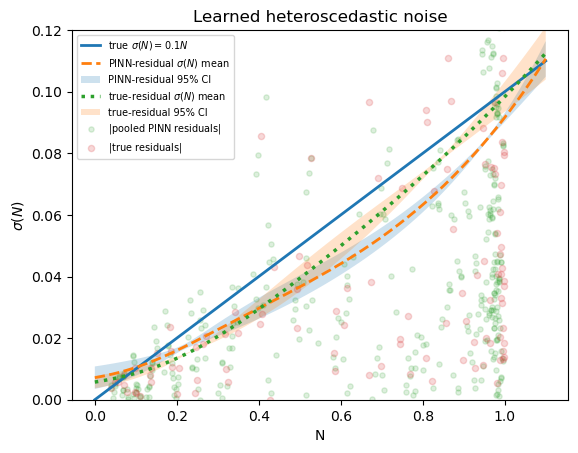

In [ ]:
plt.plot(
    N_grid.cpu().numpy(),
    sigma_true_grid.squeeze(1).cpu().numpy(),
    linewidth=2,
    label=r"true $\sigma(N)=0.1N$",
)
plt.plot(
    N_grid.cpu().numpy(),
    sigma_pinn_mean,
    "--",
    linewidth=2,
    label=r"PINN-residual $\sigma(N)$ mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_pinn_lo,
    sigma_pinn_hi,
    alpha=0.22,
    label="PINN-residual 95% CI",
)
plt.plot(
    N_grid.cpu().numpy(),
    sigma_truefit_mean,
    ":",
    linewidth=2.5,
    label=r"true-residual $\sigma(N)$ mean",
)
plt.fill_between(
    N_grid.squeeze(1).cpu().numpy(),
    sigma_truefit_lo,
    sigma_truefit_hi,
    alpha=0.22,
    label="true-residual 95% CI",
)
plt.scatter(
    N_pinn_sigma_all.cpu().numpy().squeeze(),
    np.abs(resid_pinn_sigma_all.cpu().numpy().squeeze()),
    s=14,
    alpha=0.16,
    label=r"$|$pooled PINN residuals$|$",
)
plt.scatter(
    N_true_sigma.cpu().numpy().squeeze(),
    np.abs(resid_true_sigma.cpu().numpy().squeeze()),
    s=20,
    alpha=0.18,
    label=r"$|$true residuals$|$",
)
plt.xlabel("N")
plt.ylabel(r"$\sigma(N)$")
plt.title("Learned heteroscedastic noise")
plt.legend(fontsize=7)
plt.ylim(0, 0.12)